# Step 4 — Parsing and Degradation Measurement

Extracts text back out of every PDF generated in Step 3 (`synthetic_resumes/`, tracked in
`synthetic_resumes_manifest.csv`), using **two different extraction libraries** — `pdfplumber`
and `PyMuPDF` — and compares each extraction against the original ground-truth text to compute
a **parsing degradation score** per resume, per layout condition, per extractor.

This step is independent of the classifiers — it purely measures "how much did this layout
scramble or lose the text," before any classification happens. That output feeds Step 5.


In [8]:
# Install dependencies (skip if already installed)
import sys
!{sys.executable} -m pip install -q pdfplumber pymupdf python-Levenshtein


In [9]:
import re
import pandas as pd
import pdfplumber
import pymupdf  # PyMuPDF - this is the current recommended import name (the older `fitz` import is deprecated)
import Levenshtein

MANIFEST_CSV = "synthetic_resumes_manifest.csv"   # produced by the Step 3 notebook


## Extraction functions

Two different libraries are used deliberately — they use different internal heuristics for
deciding reading order when a PDF has multiple columns or complex layout, so comparing them
against each other (not just against ground truth) is itself informative.

In [10]:
def extract_with_pdfplumber(pdf_path):
    """Extracts text page by page. Tends to read primarily left-to-right across the
    full page width, which can interleave columns rather than reading one column
    fully before the next."""
    text_parts = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text() or ""
            text_parts.append(page_text)
    return "\n".join(text_parts)


def extract_with_pymupdf(pdf_path):
    """Extracts text using PyMuPDF's block-based reading order, which tends to
    preserve column order better (left column fully, then right column)."""
    text_parts = []
    doc = pymupdf.open(pdf_path)
    for page in doc:
        text_parts.append(page.get_text())
    doc.close()
    return "\n".join(text_parts)


## Degradation scoring metrics

In [11]:
def normalize_for_comparison(text):
    """Lowercase and collapse whitespace, so pure spacing/line-break differences
    (which don't matter for classification) aren't counted as degradation."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def word_overlap_score(ground_truth, extracted):
    """Fraction of ground-truth words also found in extracted text (order-independent).
    Catches CONTENT LOSS - e.g. a word dropped entirely during extraction."""
    gt_words = set(re.findall(r"\b\w+\b", ground_truth.lower()))
    ex_words = set(re.findall(r"\b\w+\b", extracted.lower()))
    if not gt_words:
        return 1.0
    return len(gt_words & ex_words) / len(gt_words)


def edit_distance_ratio(ground_truth, extracted):
    """Levenshtein similarity ratio (1.0 = identical, 0.0 = completely different).
    Sensitive to WORD ORDER as well as content - this is what catches column-reordering
    damage (e.g. sections interleaved out of order) that word_overlap alone would miss,
    since word_overlap doesn't care what order the words come back in."""
    gt_norm = normalize_for_comparison(ground_truth)
    ex_norm = normalize_for_comparison(extracted)
    if not gt_norm and not ex_norm:
        return 1.0
    return Levenshtein.ratio(gt_norm, ex_norm)


def degradation_score(ground_truth, extracted):
    """Combined degradation score: 0 = no degradation (perfect match), 1 = total degradation.
    Averages (1 - word_overlap) and (1 - edit_ratio), so both content loss AND
    reordering/scrambling contribute to the final score."""
    wo = word_overlap_score(ground_truth, extracted)
    er = edit_distance_ratio(ground_truth, extracted)
    return 1 - ((wo + er) / 2)


## Run extraction + scoring across the full manifest

In [5]:
def process_manifest(manifest_csv=MANIFEST_CSV):
    manifest = pd.read_csv(manifest_csv)
    results = []
    for _, row in manifest.iterrows():
        pdf_path = row["pdf_path"]
        ground_truth = row["ground_truth_text"]

        extracted_plumber = extract_with_pdfplumber(pdf_path)
        extracted_pymupdf = extract_with_pymupdf(pdf_path)

        results.append({
            "resume_id": row["resume_id"],
            "category": row["category"],
            "condition": row["condition"],
            "pdf_path": pdf_path,
            "word_overlap_plumber": word_overlap_score(ground_truth, extracted_plumber),
            "edit_ratio_plumber": edit_distance_ratio(ground_truth, extracted_plumber),
            "degradation_plumber": degradation_score(ground_truth, extracted_plumber),
            "word_overlap_pymupdf": word_overlap_score(ground_truth, extracted_pymupdf),
            "edit_ratio_pymupdf": edit_distance_ratio(ground_truth, extracted_pymupdf),
            "degradation_pymupdf": degradation_score(ground_truth, extracted_pymupdf),
            # kept for Step 5 - this is the actual text that gets fed into the classifiers
            "extracted_text_pymupdf": extracted_pymupdf,
            "extracted_text_plumber": extracted_plumber,
        })
    results_df = pd.DataFrame(results)
    results_df.to_csv("degradation_results.csv", index=False)
    print(f"Processed {len(results_df)} PDFs.")
    print("Saved to degradation_results.csv")
    return results_df

degradation_df = process_manifest()
degradation_df[["resume_id", "condition", "degradation_plumber", "degradation_pymupdf"]].head(10)


Processed 580 PDFs.
Saved to degradation_results.csv


,resume_id,condition,degradation_plumber,degradation_pymupdf
0,0,clean,0.009502,0.009502
1,0,two_column,0.220839,0.009502
2,0,table_based,0.009502,0.009502
3,0,icon_headers,0.016276,0.016276
4,1,clean,0.009730,0.009730
5,1,two_column,0.208757,0.009730
6,1,table_based,0.009730,0.009730
7,1,icon_headers,0.015165,0.015165
8,2,clean,0.008870,0.008870
9,2,two_column,0.210829,0.008870


## Mean degradation by layout condition

This is the key summary table — average degradation score per layout condition, per extractor.
Higher = more damage done to the text by that layout. This is what will later be correlated
with classification accuracy drop in Step 5/6.

              degradation_plumber  degradation_pymupdf
condition                                             
clean                    0.010773             0.010773
table_based              0.010773             0.010773
two_column               0.169376             0.010826
icon_headers             0.015324             0.015324


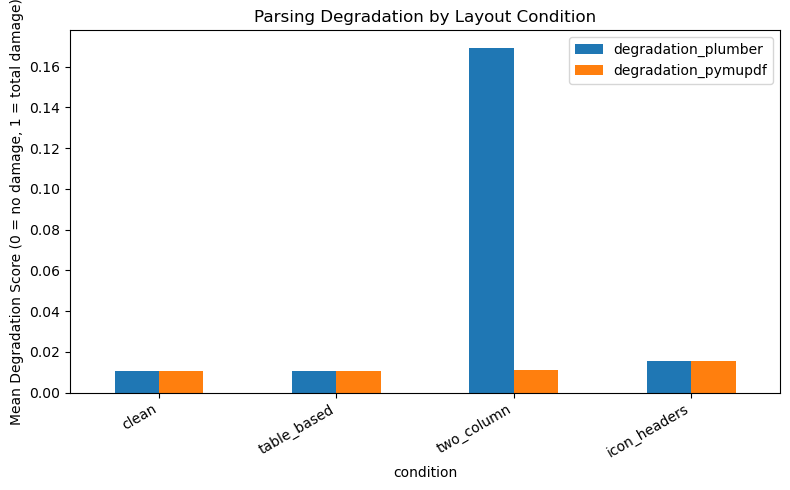

In [12]:
summary = degradation_df.groupby("condition")[["degradation_plumber", "degradation_pymupdf"]].mean()
summary = summary.sort_values("degradation_pymupdf")
print(summary)

import matplotlib.pyplot as plt

summary.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Mean Degradation Score (0 = no damage, 1 = total damage)")
plt.title("Parsing Degradation by Layout Condition")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("degradation_by_condition.png", dpi=150)
plt.show()


## Sanity check: inspect one example

Worth eyeballing at least one real example to confirm the scores reflect something real, not
just noise in the metric. Two-column layouts are a good one to check — pdfplumber and PyMuPDF
often diverge here because they use different reading-order heuristics for multi-column pages.

In [13]:
example = degradation_df[degradation_df["condition"] == "two_column"].iloc[0]

print("=== GROUND TRUTH (first 300 chars) ===")
print(example["pdf_path"])
manifest = pd.read_csv(MANIFEST_CSV)
gt_text = manifest[manifest["pdf_path"] == example["pdf_path"]].iloc[0]["ground_truth_text"]
print(gt_text[:300])

print("\n=== PDFPLUMBER EXTRACTED (first 300 chars) ===")
print(example["extracted_text_plumber"][:300])

print("\n=== PYMUPDF EXTRACTED (first 300 chars) ===")
print(example["extracted_text_pymupdf"][:300])

print(f"\nDegradation - pdfplumber: {example['degradation_plumber']:.4f} | PyMuPDF: {example['degradation_pymupdf']:.4f}")


=== GROUND TRUTH (first 300 chars) ===
synthetic_resumes/resume_0_two_column.pdf
Hobbies Playing Chess Solving Rubik s Cube Watching Series Languages English Hindi Marathi Education Details January 2014 to January 2017 Bachelor s Degree Information Technology, First Class Pune, Maharashtra JSPM s Jayawantrao Sawant College of Engineering January 2010 to January 2014 Diploma Info

=== PDFPLUMBER EXTRACTED (first 300 chars) ===
Blockchain — Resume 0 EXPERIENCE
Developing and managing user s Blockchain account
wallets and transactions. Regularly monitoring smooth
SUMMARY executions of Blockchain transactions and wallet functions
along with identifying and correcting possible errors. Writing
Hobbies Playing Chess Solving Rub

=== PYMUPDF EXTRACTED (first 300 chars) ===
Blockchain — Resume 0
SUMMARY
Hobbies Playing Chess Solving Rubik s Cube Watching
Series Languages English Hindi Marathi Education Details
January 2014 to January 2017 Bachelor s Degree
Information Technology, First Class Pu

---
### Next: Step 5 — Classification Under Formatting Stress

Load the saved DistilBERT model and the trained TF-IDF+SVM model, feed each row's
`extracted_text_pymupdf` (and/or `extracted_text_plumber`) through both, and compare predicted
category against the true `category` column — this gives per-condition accuracy/F1, which is
what actually answers the project's core question: does formatting hurt one model more than
the other?
